Import des librairies et de la base de données

In [15]:
import sys
!{sys.executable} -m pip install holidays


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import holidays

In [17]:
df = pd.read_csv(r"C:\Users\utilisateur\Downloads\wetransfer_histo_gazpar_merged-3-csv-gz_2026-01-30_1023\histo_gazpar_merged(1).csv.gz")


Préparation des variables : "trend", "hdd_workday", "hdd_weekend".

In [18]:
# Chargement et conversion des dates
df['date_parsed'] = pd.to_datetime(df['date_parsed'])
df = df.sort_values(['pce', 'date_parsed'])

# Création de la variable 'trend' (tendance temporelle)
df['trend'] = (df['date_parsed'] - df['date_parsed'].min()).dt.days

Ajout de la colonne : "is_holiday" et "is_weekend"

In [19]:
# 1. Assurez-vous que la colonne date_parsed est bien au format datetime
df['date_parsed'] = pd.to_datetime(df['date_parsed'])

# 2. Initialisation des jours fériés français sur la période du dataset
fr_holidays = holidays.France(years=range(df['date_parsed'].dt.year.min(), 
                                          df['date_parsed'].dt.year.max() + 1))

# 3. Création des trois colonnes
df['is_holiday'] = df['date_parsed'].apply(lambda x: 1 if x in fr_holidays else 0)
df['is_weekend'] = df['date_parsed'].dt.dayofweek.isin([5, 6]).astype(int)

# Création de la colonne combinée (le "OU" logique pour éviter l'overlap)
df['is_off_day'] = ((df['is_weekend'] == 1) | (df['is_holiday'] == 1)).astype(int)

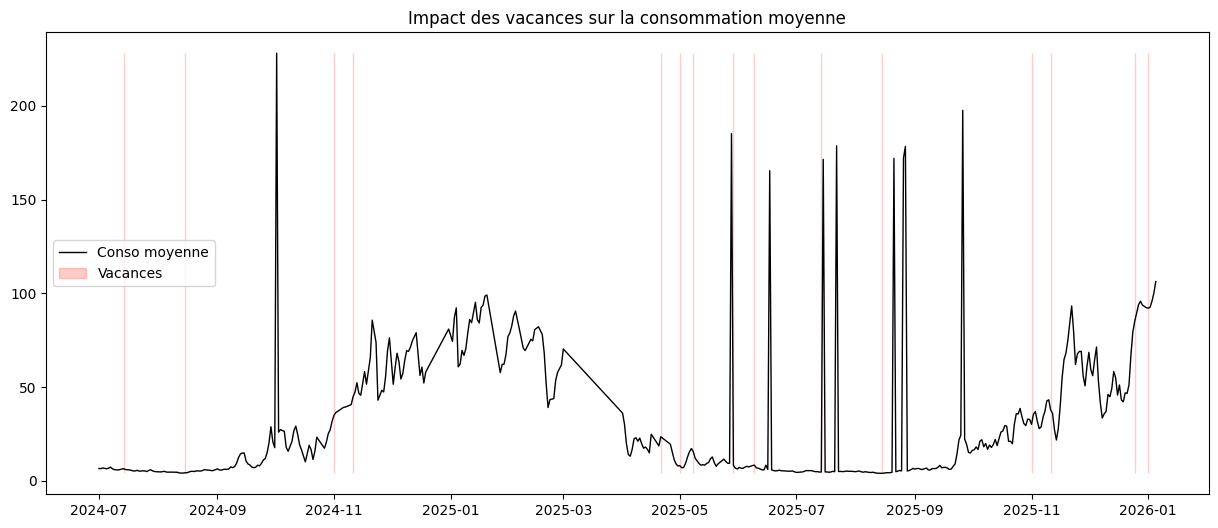

In [20]:
# 1. On prépare les données agrégées par jour
# On calcule la moyenne de conso pour que le graphique ne soit pas pollué par le nombre de compteurs
daily_stats = df.groupby('date_parsed').agg({
    'valeur_energie_conso': 'mean',
    'is_holiday': 'max'
}).reset_index()

# 2. On trace la courbe
plt.figure(figsize=(15, 6))
plt.plot(daily_stats['date_parsed'], daily_stats['valeur_energie_conso'], color='black', lw=1, label='Conso moyenne')

# 3. On colorie les zones de vacances
# On utilise fill_between pour créer des blocs propres
plt.fill_between(daily_stats['date_parsed'], 
                 daily_stats['valeur_energie_conso'].min(), 
                 daily_stats['valeur_energie_conso'].max(), 
                 where=(daily_stats['is_holiday'] == 1),
                 color='red', alpha=0.2, label='Vacances')

plt.title("Impact des vacances sur la consommation moyenne")
plt.legend()
plt.show()

Nettoyage des outliers (méthode IQR)

In [21]:
df['temp_scaled'] = (df['temperature'] - df['temperature'].mean()) / df['temperature'].std()

print("Entraînement du modèle LMM")

# Entrainement du modèle sur la simple valeur température
model_lmm = smf.mixedlm("valeur_energie_conso ~ temp_scaled", 
                        data=df, 
                        groups=df['pce'], 
                        re_formula="~temp_scaled")

# Stockage des résidus
result_lmm = model_lmm.fit(method=["lbfgs"]) 
print("Entraînement terminé !")

fixed_intercept = result_lmm.params['Intercept']
fixed_slope = result_lmm.params['temp_scaled']

re_df = pd.DataFrame.from_dict(result_lmm.random_effects, orient='index')

re_df = re_df.rename(columns={'temp_scaled': 'rand_slope'})
col_intercept = [c for c in re_df.columns if c != 'rand_slope'][0] # On trouve l'autre colonne dynamiquement
re_df = re_df.rename(columns={col_intercept: 'rand_intercept'})

re_df.index.name = 'pce'

df = df.merge(re_df, on='pce', how='left')

df['intercept_client'] = fixed_intercept + df['rand_intercept']
df['pente_client'] = fixed_slope + df['rand_slope']

# Prédiction propre au client et calcul du résidu "pur" (sans l'effet météo)
df['conso_predite'] = df['intercept_client'] + (df['pente_client'] * df['temp_scaled'])
df['conso_residu'] = df['valeur_energie_conso'] - df['conso_predite']

# Nettoyage des outliers par IQR
def remove_outliers_iqr(group):
    # L'analyse se fait uniquement sur le résidu, propre à chaque compteur
    Q1 = group['conso_residu'].quantile(0.25)
    Q3 = group['conso_residu'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # On filtre les lignes où le résidu est dans les bornes (comportement normal)
    return group[(group['conso_residu'] >= lower_bound) & (group['conso_residu'] <= upper_bound)]

print("Filtrage des valeurs aberrantes (Outliers) par PCE...")
# Application du filtre (compatible avec les versions Pandas < 2.2.0)
df_clean = df.groupby('pce').apply(remove_outliers_iqr).reset_index(drop=True)

# On supprime toutes les colonnes intermédiaires de calcul pour garder un dataframe propre
cols_to_drop = ['temp_scaled', 'rand_intercept', 'rand_slope', 'intercept_client', 
                'pente_client', 'conso_predite', 'conso_residu']
df_clean = df_clean.drop(columns=[c for c in cols_to_drop if c in df_clean.columns])

# Si vous aviez une colonne 'year', on filtre pour ne garder que les compteurs présents sur >1 an
if 'year' in df_clean.columns:
    pce_counts = df_clean.groupby('pce')['year'].nunique()
    consistent_pce = pce_counts[pce_counts >= 2].index
    df_final = df_clean[df_clean['pce'].isin(consistent_pce)]
else:
    df_final = df_clean.copy()

print(f"Terminé ! Nombre de lignes restantes : {len(df_final)}")

Entraînement du modèle LMM


C:\Users\utilisateur\AppData\Roaming\Python\Python313\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


Entraînement terminé !
Filtrage des valeurs aberrantes (Outliers) par PCE...


C:\Users\utilisateur\AppData\Local\Temp\ipykernel_18468\416375530.py:49: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_clean = df.groupby('pce').apply(remove_outliers_iqr).reset_index(drop=True)


Terminé ! Nombre de lignes restantes : 2667525


In [ ]:
# 1. On prépare les données agrégées par jour
# On calcule la moyenne de conso pour que le graphique ne soit pas pollué par le nombre de compteurs
daily_stats = df_final.groupby('date_parsed').agg({
    'valeur_energie_conso': 'mean',
    'is_off_day': 'max'
}).reset_index()

# 2. On trace la courbe
plt.figure(figsize=(15, 6))
plt.plot(daily_stats['date_parsed'], daily_stats['valeur_energie_conso'], color='black', lw=1, label='Conso moyenne')

# 3. On colorie les zones de vacances
# On utilise fill_between pour créer des blocs propres
plt.fill_between(daily_stats['date_parsed'], 
                 daily_stats['valeur_energie_conso'].min(), 
                 daily_stats['valeur_energie_conso'].max(), 
)

plt.title("Impact des vacances sur la consommation moyenne")
plt.legend()
plt.show()

SyntaxError: '(' was never closed (1277875163.py, line 14)

Application de LMM

In [23]:
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

# 1. Préparation des données
df_lmm = df_final.copy()

# On s'assure que les dates sont bien au format datetime
df_lmm['date_parsed'] = pd.to_datetime(df_lmm['date_parsed'])

# --- FILTRAGE DES HDD NULS ---
# On retire les lignes où HDD est égal à 0 car elles sont considérées comme des valeurs manquantes
df_lmm = df_lmm[df_lmm['hdd'] > 0].copy()

# 2. Définition de la formule (SANS sin_month, cos_month, sin_week, cos_week)
# On garde les variables principales : hdd, trend et les vacances
formula = "valeur_energie_conso ~ hdd + trend + is_holiday + is_weekend"

print(f"Démarrage du modèle LMM sur {len(df_lmm)} lignes (HDD > 0)...")
        
# 3. Entraînement du modèle Mixed Linear Model
# re_formula="~hdd" : permet d'avoir une pente (sensibilité thermique) différente par compteur (PCE)
model_lmm = smf.mixedlm(formula, data=df_lmm, groups=df_lmm["pce"], re_formula="~hdd")

# Utilisation de la méthode lbfgs pour une meilleure convergence
result_lmm = model_lmm.fit(method=["lbfgs"], maxiter=600)

Démarrage du modèle LMM sur 1515947 lignes (HDD > 0)...


Comparaison avec OLS

Entraînement du modèle LMM en cours...
Entraînement des modèles OLS individuels en cours...

=== RÉSUMÉ DES COEFFICIENTS FIXES (LMM) ===
                   Coef. Std.Err.        z  P>|z|  [0.025  0.975]
Intercept          6.201    0.148   41.972  0.000   5.911   6.490
hdd                5.614    0.043  130.742  0.000   5.530   5.698
trend              0.000    0.000    3.917  0.000   0.000   0.000
is_off_day        -0.631    0.027  -23.433  0.000  -0.683  -0.578
Group Var        148.575    0.173                                
Group x hdd Cov   11.074    0.036                                
hdd Var           13.497    0.015                                

=== COMPARAISON DE LA SENSIBILITÉ THERMIQUE (HDD) ===
-> Coefficient HDD (LMM global)       : 5.6139
-> Moyenne des coefficients HDD (OLS) : 5.4830


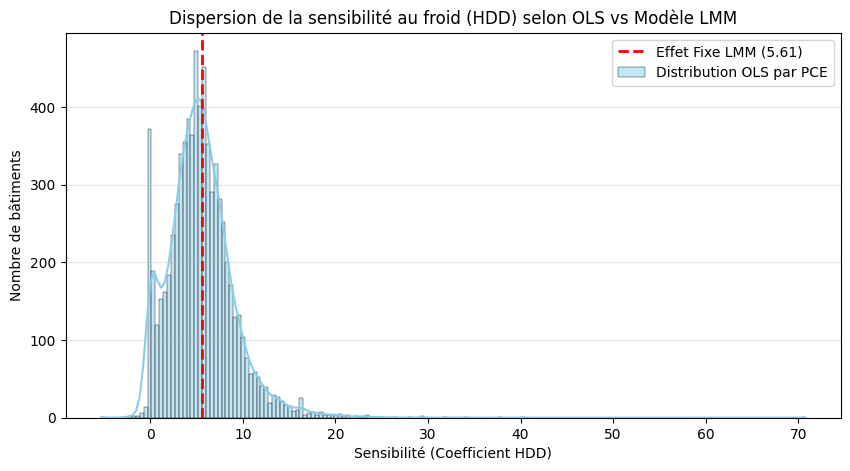

In [24]:
df_comp = df_final.copy()

# 3. Filtrage : on retire les HDD nuls
df_comp = df_comp[df_comp['hdd'] > 0].copy()

# 4. Formule du modèle (sans hdd_workday / hdd_offday)
# On utilise is_off_day pour capter la baisse globale de conso les jours chômés
formula = "valeur_energie_conso ~ hdd + trend + is_off_day"

# ==========================================
# ENTRAÎNEMENT DES MODÈLES
# ==========================================

# --- Modèle 1 : LMM (Effets Mixtes Globaux) ---
print("Entraînement du modèle LMM en cours...")
model_lmm = smf.mixedlm(formula, data=df_comp, groups=df_comp["pce"], re_formula="~hdd")
result_lmm = model_lmm.fit(method=["lbfgs"], maxiter=600)

# --- Modèle 2 : OLS (Individuels par PCE pour comparaison) ---
print("Entraînement des modèles OLS individuels en cours...")
results_ols = []

for pce, group in df_comp.groupby('pce'):
    if len(group) > 20:  # On s'assure d'avoir assez de points pour la régression
        res = smf.ols(formula, data=group).fit()
        results_ols.append({
            'pce': pce,
            'intercept_ols': res.params['Intercept'],
            'hdd_ols': res.params['hdd'],
            'is_off_day_ols': res.params.get('is_off_day', np.nan),
            'r2': res.rsquared
        })

df_results_ols = pd.DataFrame(results_ols)

# ==========================================
# AFFICHAGE DES RÉSULTATS ET COMPARAISON
# ==========================================

print("\n=== RÉSUMÉ DES COEFFICIENTS FIXES (LMM) ===")
# On affiche uniquement le tableau principal des paramètres pour plus de clarté
print(result_lmm.summary().tables[1])

print("\n=== COMPARAISON DE LA SENSIBILITÉ THERMIQUE (HDD) ===")
hdd_mean_lmm = result_lmm.params['hdd']
hdd_mean_ols = df_results_ols['hdd_ols'].mean()

print(f"-> Coefficient HDD (LMM global)       : {hdd_mean_lmm:.4f}")
print(f"-> Moyenne des coefficients HDD (OLS) : {hdd_mean_ols:.4f}")

# --- Graphique de distribution ---
plt.figure(figsize=(10, 5))
sns.histplot(df_results_ols['hdd_ols'], kde=True, color='skyblue', label='Distribution OLS par PCE')
plt.axvline(hdd_mean_lmm, color='red', linestyle='--', linewidth=2, label=f'Effet Fixe LMM ({hdd_mean_lmm:.2f})')

plt.title("Dispersion de la sensibilité au froid (HDD) selon OLS vs Modèle LMM")
plt.xlabel("Sensibilité (Coefficient HDD)")
plt.ylabel("Nombre de bâtiments")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

Résultats du LMM

In [25]:
# Résultats du modèle
print(result_lmm.summary())
        
# Effets aléatoires:
print("Exemple d'Effets Aléatoire:")
print(pd.DataFrame(result_lmm.random_effects).T.head(5))

              Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: valeur_energie_conso
No. Observations: 1515947 Method:             REML                
No. Groups:       7368    Scale:              233.7842            
Min. group size:  3       Log-Likelihood:     -6322247.1710       
Max. group size:  461     Converged:          Yes                 
Mean group size:  205.7                                           
-------------------------------------------------------------------
                   Coef.   Std.Err.     z     P>|z|  [0.025  0.975]
-------------------------------------------------------------------
Intercept           6.201     0.148   41.972  0.000   5.911   6.490
hdd                 5.614     0.043  130.742  0.000   5.530   5.698
trend               0.000     0.000    3.917  0.000   0.000   0.000
is_off_day         -0.631     0.027  -23.433  0.000  -0.683  -0.578
Group Var         148.575     0.173                                
Gr

Stockage des résultats dans "df_results"

In [26]:
# Extraction des Effets Fixes (Population globale)
beta_hdd_fixed = result_lmm.params['hdd']

# Extraction des Effets Aléatoires (Spécifiques par client): le dico result_lmm.random_effects contient les écarts pour chaque PCE
re_df = pd.DataFrame.from_dict(result_lmm.random_effects, orient='index')
re_df = re_df.rename(columns={'hdd': 'hdd_random_slope', 'Group': 'intercept_random'})
re_df.index.name = 'pce'

# Fusion avec les données d'origine utilisées dans le modèle
df_results = df_lmm.copy()
df_results = df_results.merge(re_df, on='pce', how='left')

# Calcul de la pente totale : Pente Client = Pente Moyenne (Fixed) + Écart Client (Random)
df_results['total_hdd_slope'] = beta_hdd_fixed + df_results['hdd_random_slope']

# Calcul de la Consommation Normalisée (On retire l'effet météo spécifique à ce client pour ne garder que le comportement : Conso_Norm = Conso_Reelle - (Sensibilité_Client * Météo)
df_results['conso_norm'] = df_results['valeur_energie_conso'] - (df_results['total_hdd_slope'] * df_results['hdd'])

Evolution d'une années sur l'autre (pb car ici juste 1 an)

In [27]:
# Agrégation Mensuelle : On fait la moyenne des consos normalisées par mois
summary_lmm = df_results.groupby(['year', 'month'])['conso_norm'].mean().reset_index()

# Pivot pour comparer les années (2025 vs 2024)
pivot_lmm = summary_lmm.pivot(index='month', columns='year', values='conso_norm')

# Calcul de l'évolution
if 2024 in pivot_lmm.columns and 2025 in pivot_lmm.columns:
    pivot_lmm['Evolution_2025_vs_2024 (%)'] = ((pivot_lmm[2025] - pivot_lmm[2024]) / pivot_lmm[2024]) * 100
    
    print("\n RÉSULTATS FINAUX ")
    print("Évolution de la consommation corrigée du climat (Demand Destruction) :")
    print(pivot_lmm[['Evolution_2025_vs_2024 (%)']].round(2))
    
    avg_drop = pivot_lmm['Evolution_2025_vs_2024 (%)'].mean()
    print(f"\n>> Moyenne globale de la baisse sur la période : {avg_drop:.2f}%")
else:
    print("Pas assez de données communes pour comparer les années.")


 RÉSULTATS FINAUX 
Évolution de la consommation corrigée du climat (Demand Destruction) :
year   Evolution_2025_vs_2024 (%)
month                            
1                             NaN
2                             NaN
3                             NaN
4                             NaN
5                             NaN
6                             NaN
7                            3.09
8                            0.70
9                          322.56
10                          12.26
11                           2.06
12                         -16.14

>> Moyenne globale de la baisse sur la période : 54.09%


Réprésentation graphique des résultats
- 1 : Scatter plot pour individus
- 2 : Evolution de la conso sans l'effet météo

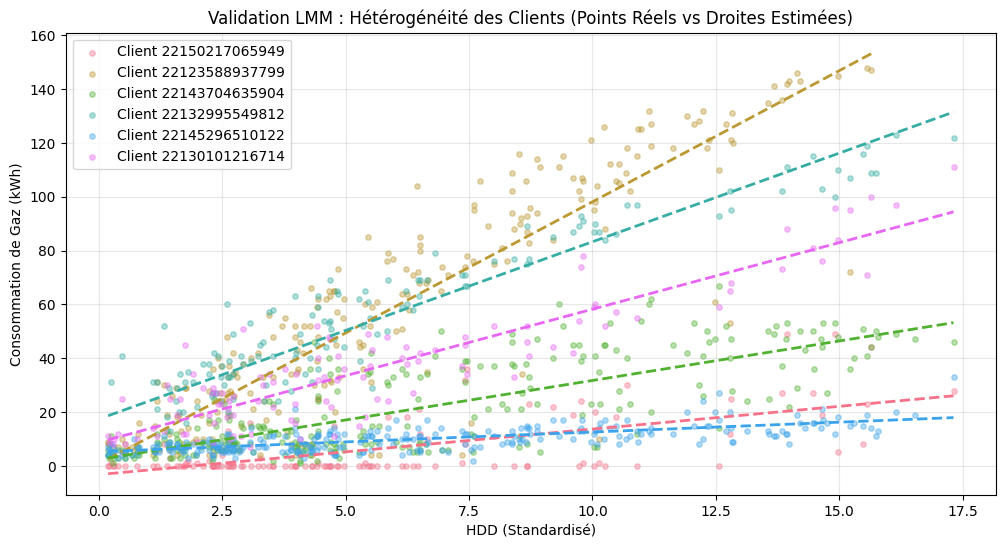

In [28]:
# Objectif : Montrer que chaque client réagit différemment au froid (Pentes aléatoires)

# Sélection de 6 clients aléatoires
sample_pces = np.random.choice(df_results['pce'].unique(), 6, replace=False)
subset_plot = df_results[df_results['pce'].isin(sample_pces)].copy()

plt.figure(figsize=(12, 6))

# Palette de couleurs pour distinguer les clients
colors = sns.color_palette("husl", len(sample_pces))

for i, pce in enumerate(sample_pces):
    pce_data = subset_plot[subset_plot['pce'] == pce]
    color = colors[i]
    
    # Nuage de points
    plt.scatter(pce_data['hdd'], pce_data['valeur_energie_conso'], 
                alpha=0.4, s=15, color=color, label=f"Client {pce}")
    
    # Droite du Modèle LMM (Pente spécifique à ce client)
    # y = (Intercept_Fixe + Intercept_Random) + (Pente_Fixe + Pente_Random) * X
    intercept_fixed = result_lmm.params['Intercept']
    intercept_total = intercept_fixed + pce_data['intercept_random'].iloc[0]
    slope_total = pce_data['total_hdd_slope'].iloc[0]
    
    # Création de la ligne de régression
    x_vals = np.array([pce_data['hdd'].min(), pce_data['hdd'].max()])
    y_vals = intercept_total + slope_total * x_vals
    
    plt.plot(x_vals, y_vals, color=color, linewidth=2, linestyle='--')

plt.title("Validation LMM : Hétérogénéité des Clients (Points Réels vs Droites Estimées)")
plt.xlabel("HDD (Standardisé)")
plt.ylabel("Consommation de Gaz (kWh)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

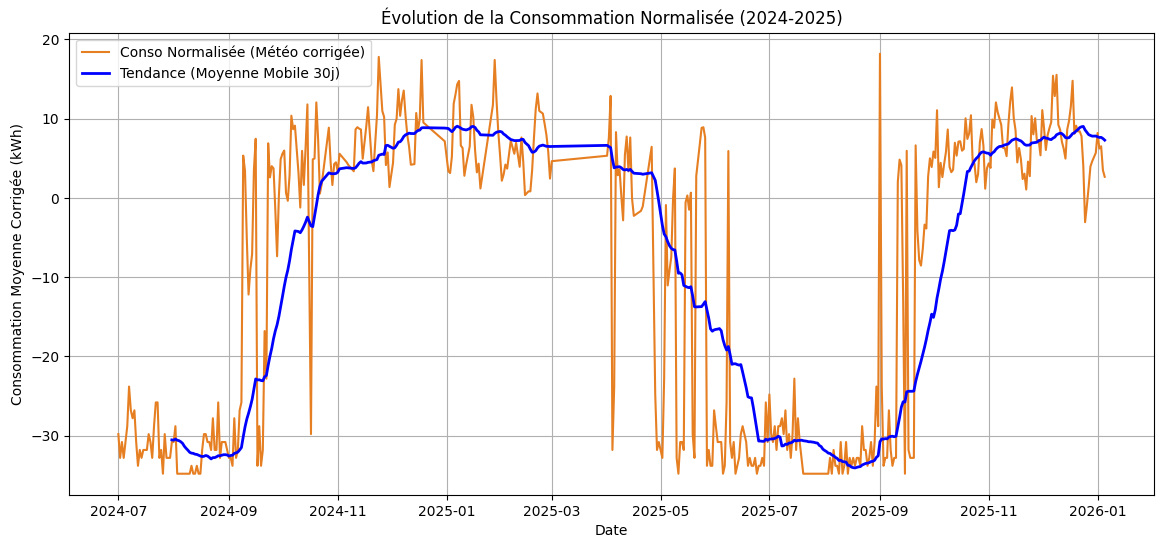

In [33]:
# Objectif : Voir la courbe de consommation "nettoyée" de la météo
plt.figure(figsize=(14, 6))

# On agrège par jour pour alléger le graphique
daily_trend = df_results.groupby('date_parsed')['conso_norm'].mean()

# Tracé de la courbe
plt.plot(daily_trend.index, daily_trend.values, color='#e67e22', linewidth=1.5, label='Conso Normalisée (Météo corrigée)')

# Ajout d'une moyenne mobile pour voir la tendance de fond (Trend)
plt.plot(daily_trend.rolling(window=30).mean().index, 
         daily_trend.rolling(window=30).mean().values, 
         color='blue', linewidth=2, linestyle='-', label='Tendance (Moyenne Mobile 30j)')

plt.title("Évolution de la Consommation Normalisée (2024-2025)")
plt.ylabel("Consommation Moyenne Corrigée (kWh)")
plt.xlabel("Date")
plt.legend()
plt.grid(True)
plt.show()

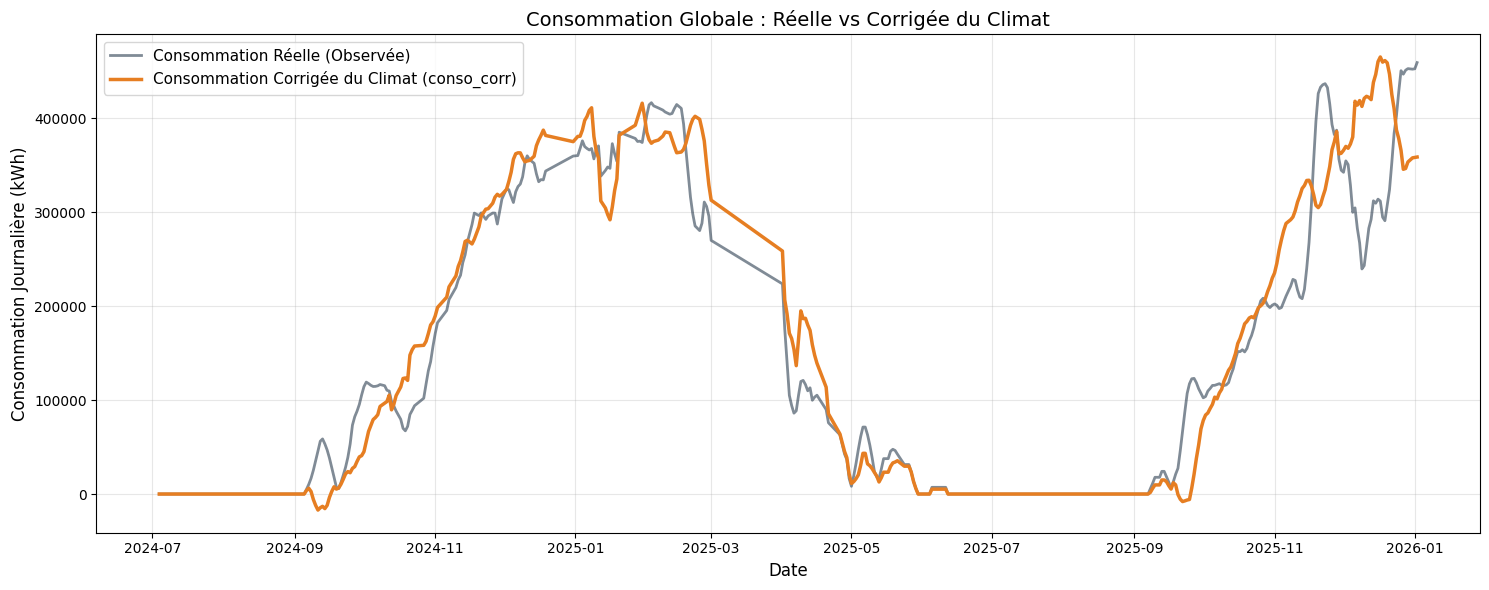

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. CALCUL DE LA COLONNE 'conso_corr'
# =========================================================

# Extraire la pente fixe globale (coefficient moyen du hdd)
fixed_slope = result_lmm.params['hdd']

# Récupérer les pentes spécifiques pour chaque PCE (Fixe + Aléatoire)
pce_slopes = {pce: fixed_slope + effects['hdd'] for pce, effects in result_lmm.random_effects.items()}

# Assigner cette pente à chaque ligne (et utiliser la pente moyenne si un PCE n'a pas d'effet aléatoire)
df_comp['slope_pce'] = df_comp['pce'].map(pce_slopes).fillna(fixed_slope)

# Calcul final de la consommation corrigée
df_comp['conso_corr'] = df_comp['valeur_energie_conso'] - df_comp['slope_pce'] * (df_comp['hdd'] - df_comp["hdd_ref"])

# =========================================================
# 2. AGRÉGATION ET GRAPHIQUE
# =========================================================
# On somme les consommations de tous les compteurs par jour
daily_real = df_comp.groupby('date_parsed')['valeur_energie_conso'].sum()
daily_corr = df_comp.groupby('date_parsed')['conso_corr'].sum()

# Lissage sur 7 jours (Moyenne mobile) pour un graphique propre et lisible
window = 7
real_smooth = daily_real.rolling(window=window, center=True).mean()
corr_smooth = daily_corr.rolling(window=window, center=True).mean()

# Création du graphique
plt.figure(figsize=(15, 6))

# Courbe de la consommation brute observée
plt.plot(real_smooth.index, real_smooth.values, 
         label='Consommation Réelle (Observée)', 
         color='#2c3e50', alpha=0.6, linewidth=2)

# Courbe de la consommation corrigée (lissée de l'effet météo)
plt.plot(corr_smooth.index, corr_smooth.values, 
         label='Consommation Corrigée du Climat (conso_corr)', 
         color='#e67e22', linewidth=2.5)

plt.title("Consommation Globale : Réelle vs Corrigée du Climat", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Consommation Journalière (kWh)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()